# Notebook 02: Money-Inflation TWFE (Mainline)

This is the canonical short-run notebook. It estimates within-country annual money-inflation associations using country and year fixed effects.

Non-mainline material belongs outside this notebook. IV, inflation-targeting, Phillips-curve forecasts, and other side paths are not part of the main claim here.


## Estimand and guardrails

The main model is:

`inflation_it = beta * m2_growth_it + country FE + year FE + error_it`

- `beta` is a descriptive within-country annual association, not a causal policy effect.
- Country fixed effects remove time-invariant country differences.
- Year fixed effects remove global year shocks common to all countries.
- Standard errors are clustered by country unless explicitly marked otherwise.
- The clean sample drops countries with any inflation year above 40 percent.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from linearmodels.panel import PanelOLS

warnings.filterwarnings("ignore")


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "02_data/analysis_ready/macro_growth_merged.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory")


ROOT = find_project_root(Path.cwd().resolve())
PANEL_PATH = ROOT / "02_data/analysis_ready/macro_growth_merged.csv"
CONTROLS_PATH = ROOT / "02_data/supporting/wb_controls_1991_2024.csv"
FIG_DIR = ROOT / "04_current_results/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RESTRICTED_CONTROLS = ["trade_open", "pop_growth", "investment_share"]

for p in [PANEL_PATH, CONTROLS_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

ROOT


PosixPath('/Users/stevenchung/Desktop/P12B_File/Monetary_Panel')

### Load panel data


In [2]:
base = pd.read_csv(PANEL_PATH)
controls = pd.read_csv(CONTROLS_PATH)

panel = (
    base.merge(controls, on=["Country Name", "year"], how="left")
        .rename(columns={"Country Name": "country"})
        .sort_values(["country", "year"])
        .copy()
)

panel_summary = pd.DataFrame({
    "metric": ["rows", "countries", "year_min", "year_max", "clean_countries"],
    "value": [
        len(panel),
        panel["country"].nunique(),
        int(panel["year"].min()),
        int(panel["year"].max()),
        panel.loc[panel["sample_low_inflation"] == 1, "country"].nunique(),
    ],
})
display(panel_summary)


,metric,value
0,rows,4750
1,countries,160
2,year_min,1991
3,year_max,2024
4,clean_countries,123


### TWFE helpers


In [3]:
def run_fe(df, outcome, controls=None, cov_type="clustered", **fit_kwargs):
    controls = controls or []
    cols = ["country", "year", outcome, "m2_growth", *controls]
    fit_data = df[cols].dropna().set_index(["country", "year"]).sort_index()
    if fit_data.empty:
        raise ValueError("No complete observations for requested FE model")

    rhs = "m2_growth" + (" + " + " + ".join(controls) if controls else "")
    formula = f"{outcome} ~ 1 + {rhs} + EntityEffects + TimeEffects"

    if cov_type == "clustered" and not fit_kwargs:
        fit_kwargs = {"cluster_entity": True}
    return PanelOLS.from_formula(formula, data=fit_data).fit(cov_type=cov_type, **fit_kwargs)


def result_row(label, sample, outcome, res, cov="clustered_by_country"):
    return {
        "label": label,
        "sample": sample,
        "outcome": outcome,
        "covariance": cov,
        "coef_m2_growth": float(res.params["m2_growth"]),
        "se": float(res.std_errors["m2_growth"]),
        "t_stat": float(res.tstats["m2_growth"]),
        "p_value": float(res.pvalues["m2_growth"]),
        "within_r2": float(res.rsquared_within),
        "nobs": int(res.nobs),
    }


def fit_inflation_twfe(df, cov_type="clustered", **fit_kwargs):
    if cov_type == "clustered" and not fit_kwargs:
        fit_kwargs = {"cluster_entity": True}
    fit_df = df.dropna(subset=["inflation", "m2_growth"]).set_index(["country", "year"]).sort_index()
    formula = "inflation ~ 1 + m2_growth + EntityEffects + TimeEffects"
    return PanelOLS.from_formula(formula, data=fit_df).fit(cov_type=cov_type, **fit_kwargs)


### Baseline TWFE models

Inflation is the main outcome. GDP growth is retained only as a secondary real-side sanity check, not as a headline claim.


In [4]:
fe_infl_base = run_fe(panel, "inflation", controls=[])
fe_gdp_base = run_fe(panel, "gdp_growth", controls=[])
fe_infl_ctrl = run_fe(panel, "inflation", controls=RESTRICTED_CONTROLS)
fe_gdp_ctrl = run_fe(panel, "gdp_growth", controls=RESTRICTED_CONTROLS)

fe_table = pd.DataFrame([
    result_row("baseline", "full", "inflation", fe_infl_base),
    result_row("baseline", "full", "gdp_growth", fe_gdp_base),
    result_row("with_controls", "full", "inflation", fe_infl_ctrl),
    result_row("with_controls", "full", "gdp_growth", fe_gdp_ctrl),
])
display(fe_table)


,label,sample,outcome,covariance,coef_m2_growth,se,t_stat,p_value,within_r2,nobs
0,baseline,full,inflation,clustered_by_country,0.664851,0.177025,3.755693,0.000175,0.504056,4750
1,baseline,full,gdp_growth,clustered_by_country,-0.005980,0.010363,-0.577053,0.563932,0.000047,4750
2,with_controls,full,inflation,clustered_by_country,0.595898,0.201089,2.963358,0.003062,0.439483,3929
3,with_controls,full,gdp_growth,clustered_by_country,-0.004923,0.009855,-0.499595,0.617390,0.040876,3929


### Full vs clean sample

This is the first main check. If the clean-sample coefficient is much smaller than the full-sample coefficient, the full-sample estimate is partly driven by high-inflation episodes.


In [5]:
clean_panel = panel[panel["sample_low_inflation"] == 1].copy()

core_rows = [
    result_row("baseline", "full", "inflation", fe_infl_base),
    result_row("with_controls", "full", "inflation", fe_infl_ctrl),
    result_row("baseline", "clean_low_inflation", "inflation", fit_inflation_twfe(clean_panel)),
    result_row("with_controls", "clean_low_inflation", "inflation", run_fe(clean_panel, "inflation", controls=RESTRICTED_CONTROLS)),
]
core_table = pd.DataFrame(core_rows)
display(core_table)


,label,sample,outcome,covariance,coef_m2_growth,se,t_stat,p_value,within_r2,nobs
0,baseline,full,inflation,clustered_by_country,0.664851,0.177025,3.755693,0.000175,0.504056,4750
1,with_controls,full,inflation,clustered_by_country,0.595898,0.201089,2.963358,0.003062,0.439483,3929
2,baseline,clean_low_inflation,inflation,clustered_by_country,0.040292,0.021592,1.866040,0.062120,0.029238,3639
3,with_controls,clean_low_inflation,inflation,clustered_by_country,0.039355,0.022240,1.769531,0.076910,0.035231,3057


### Pre/post-2008 TWFE split

This is part of the main story, not a side robustness check. The same clean-sample TWFE specification is estimated separately across monetary-regime periods.


In [6]:
periods = {
    "1991-2007_pre_2008": (1991, 2007),
    "2008-2019_qe_era": (2008, 2019),
    "2020-2024_covid_post": (2020, 2024),
}

period_rows = []
for label, (y0, y1) in periods.items():
    sub = clean_panel[(clean_panel["year"] >= y0) & (clean_panel["year"] <= y1)].copy()
    sub_fit = sub.dropna(subset=["inflation", "m2_growth"])
    if len(sub_fit) < 50:
        continue
    res = fit_inflation_twfe(sub)
    row = result_row("period_split", label, "inflation", res)
    row["year_min"] = y0
    row["year_max"] = y1
    row["countries"] = int(sub_fit["country"].nunique())
    period_rows.append(row)

period_table = pd.DataFrame(period_rows)
display(period_table[["sample", "coef_m2_growth", "se", "p_value", "within_r2", "nobs", "countries"]])


,sample,coef_m2_growth,se,p_value,within_r2,nobs,countries
0,1991-2007_pre_2008,0.112794,0.018601,1.648698e-09,0.067288,1764,119
1,2008-2019_qe_era,0.000457,0.002093,8.272873e-01,0.000306,1398,123
2,2020-2024_covid_post,-0.013850,0.030944,6.547154e-01,0.005279,477,107


### Compact robustness layer

These rows check whether the main short-run pattern is just a COVID-year artifact or an inference artifact. They are diagnostics for the same descriptive TWFE estimand, not new claims.


In [7]:
panel_no_covid = panel[~panel["year"].isin([2020, 2021])].copy()
clean_no_covid = panel_no_covid[panel_no_covid["sample_low_inflation"] == 1].copy()

robustness_rows = [
    result_row("clustered", "full", "inflation", fe_infl_base),
    result_row("clustered", "full_ex_2020_2021", "inflation", fit_inflation_twfe(panel_no_covid)),
    result_row("clustered", "clean_low_inflation", "inflation", fit_inflation_twfe(clean_panel)),
    result_row("clustered", "clean_ex_2020_2021", "inflation", fit_inflation_twfe(clean_no_covid)),
    result_row(
        "driscoll_kraay_bw4",
        "full",
        "inflation",
        fit_inflation_twfe(panel, cov_type="kernel", kernel="bartlett", bandwidth=4),
        cov="driscoll_kraay_bw4",
    ),
    result_row(
        "driscoll_kraay_bw4",
        "clean_low_inflation",
        "inflation",
        fit_inflation_twfe(clean_panel, cov_type="kernel", kernel="bartlett", bandwidth=4),
        cov="driscoll_kraay_bw4",
    ),
]
robustness_table = pd.DataFrame(robustness_rows)
display(robustness_table[["label", "sample", "coef_m2_growth", "se", "t_stat", "p_value", "nobs"]])


,label,sample,coef_m2_growth,se,t_stat,p_value,nobs
0,clustered,full,0.664851,0.177025,3.755693,0.000175,4750
1,clustered,full_ex_2020_2021,0.664123,0.180085,3.687832,0.000229,4479
2,clustered,clean_low_inflation,0.040292,0.021592,1.866040,0.062120,3639
3,clustered,clean_ex_2020_2021,0.040522,0.022092,1.834211,0.066713,3431
4,driscoll_kraay_bw4,full,0.664851,0.225793,2.944519,0.003251,4750
5,driscoll_kraay_bw4,clean_low_inflation,0.040292,0.027670,1.456181,0.145433,3639


### Between-vs-within wedge

This figure compares two questions using the same clean country panel:

- Between countries: do countries with higher average M2 growth also have higher average inflation?
- Within countries: do year-to-year deviations in M2 growth line up with year-to-year deviations in inflation?


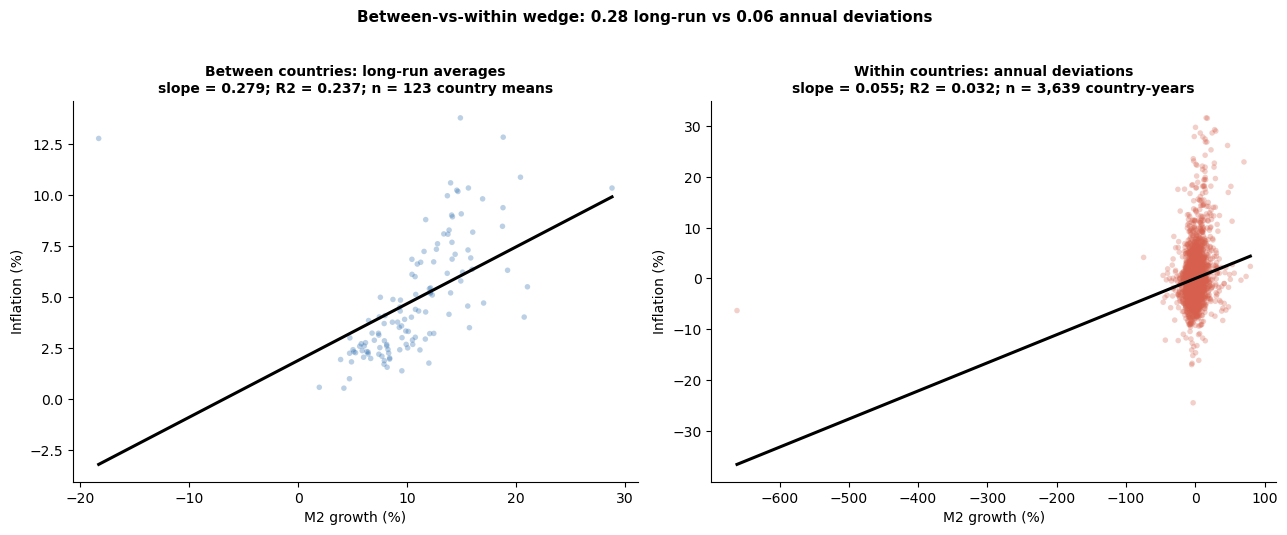

In [8]:
clean = clean_panel.dropna(subset=["m2_growth", "inflation"]).copy()

country_means = (
    clean.groupby("country", as_index=False)[["m2_growth", "inflation"]]
    .mean()
    .dropna(subset=["m2_growth", "inflation"])
)

clean["m2_dm"] = clean["m2_growth"] - clean.groupby("country")["m2_growth"].transform("mean")
clean["inf_dm"] = clean["inflation"] - clean.groupby("country")["inflation"].transform("mean")
within = clean.dropna(subset=["m2_dm", "inf_dm"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
plot_specs = [
    (
        country_means["m2_growth"] * 100,
        country_means["inflation"] * 100,
        "Between countries: long-run averages",
        "#2166ac",
        f"n = {len(country_means)} country means",
    ),
    (
        within["m2_dm"] * 100,
        within["inf_dm"] * 100,
        "Within countries: annual deviations",
        "#d6604d",
        f"n = {len(within):,} country-years",
    ),
]

slopes = []
for ax, (x, y, title, color, subtitle) in zip(axes, plot_specs):
    slope, intercept, r, _, _ = stats.linregress(x.to_numpy(), y.to_numpy())
    slopes.append(slope)
    ax.scatter(x, y, alpha=0.30, s=16, color=color, edgecolors="none")
    xfit = np.linspace(float(x.min()), float(x.max()), 100)
    ax.plot(xfit, intercept + slope * xfit, color="black", lw=2.2)
    ax.set_title(f"{title}\nslope = {slope:.3f}; R2 = {r**2:.3f}; {subtitle}", fontsize=10, fontweight="bold")
    ax.set_xlabel("M2 growth (%)")
    ax.set_ylabel("Inflation (%)")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Between-vs-within wedge: {slopes[0]:.2f} long-run vs {slopes[1]:.2f} annual deviations",
    fontsize=11,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
fig.savefig(FIG_DIR / "between_within_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()


### Main read


In [9]:
print("Main read:")
print("1. The main coefficient is a descriptive within-country annual association, not a causal policy multiplier.")
print("2. Full-sample TWFE is positive, but the clean low-inflation coefficient is much smaller.")
print("3. The clean-sample short-run association is concentrated before 2008 and weak after 2008.")
print("4. COVID-year exclusions and DK standard errors are diagnostics; they do not create a separate causal design.")
print("5. The between-vs-within wedge explains why long-run cross-country evidence and short-run TWFE can differ.")


Main read:
1. The main coefficient is a descriptive within-country annual association, not a causal policy multiplier.
2. Full-sample TWFE is positive, but the clean low-inflation coefficient is much smaller.
3. The clean-sample short-run association is concentrated before 2008 and weak after 2008.
4. COVID-year exclusions and DK standard errors are diagnostics; they do not create a separate causal design.
5. The between-vs-within wedge explains why long-run cross-country evidence and short-run TWFE can differ.
